#### Data Source

Wine Quality Dataset

Source:
UCI Machine Learning Repository

Reference:
Cortez et al. (2009)

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/winequality-red.csv", sep=";")

In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


The describe() method shows a summary of the numerical attributes.

In [4]:
df["quality"].value_counts(normalize=True)

quality
5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: proportion, dtype: float64

## Target Variable Distribution

The target variable, **`quality`**, contains six unique wine quality scores ranging from **3 to 8**.

The distribution of quality scores is imbalanced:

* A quality score of **5** represents the largest proportion of the dataset at approximately **42%** of all observations.
* A quality score of **3** represents the smallest proportion at approximately **0.6%** of observations.

The majority of wines in the dataset are rated between **5 and 6**, while extreme quality ratings (3 and 8) are underrepresented.

This imbalance should be considered during model development because machine learning models may become biased toward the more common quality scores. Model evaluation should include appropriate metrics and analysis of predictions across all quality categories to ensure performance is not dominated by the majority class.

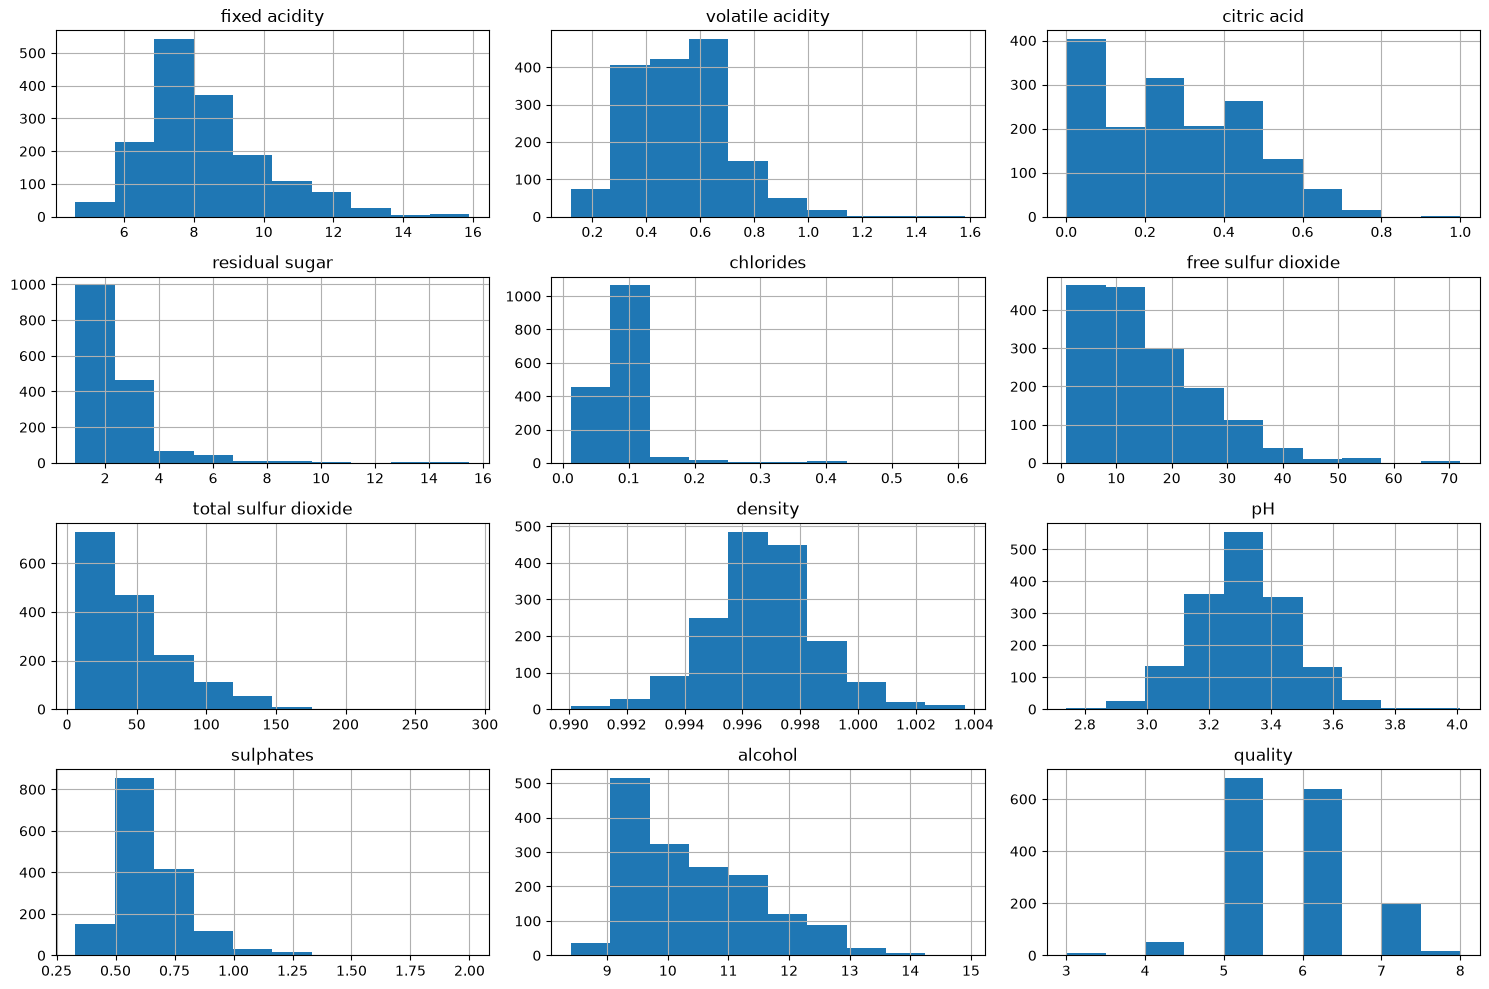

In [6]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

#### Histograms

Histograms were created for each variable to examine their distributions and identify potential skewness or unusual patterns.

The histograms show that:

* **Fixed acidity**, **volatile acidity**, **citric acid**, **residual sugar**, **chlorides**, **free sulfur dioxide**, **total sulfur dioxide**, **sulphates**, and **alcohol** exhibit **right-skewed** distributions. Most observations are concentrated at lower values, with fewer observations extending toward higher values.

* **Density** and **pH** appear to have **approximately symmetric** distributions, with observations concentrated around their central values.

* **Quality** is a discrete variable with six possible scores (3 through 8). Its distribution is imbalanced, with quality scores of **5** and **6** occurring most frequently and the extreme scores (**3** and **8**) occurring much less often.

Understanding these distributions is important because skewed variables may influence model performance and can inform later preprocessing decisions, such as applying feature transformations or handling outliers.


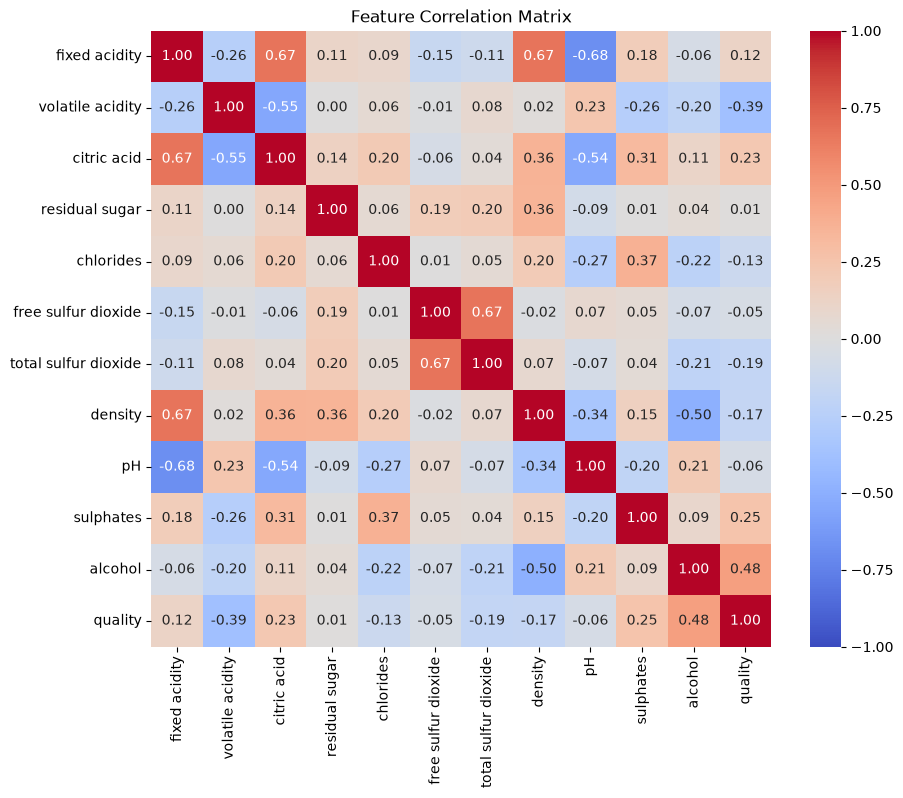

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

#### Correlation Heatmap

A correlation heatmap was used to examine the linear relationships between the physicochemical properties and the target variable, **`quality`**.

The features with the strongest correlations to wine quality are:

| Feature          | Correlation with Quality |
| ---------------- | -----------------------: |
| Alcohol          |                 **0.48** |
| Volatile acidity |                **-0.39** |
| Sulphates        |                 **0.25** |
| Citric acid      |                 **0.23** |

These results suggest that:

* **Alcohol** has the strongest positive correlation with wine quality, indicating that wines with higher alcohol content tend to receive higher quality ratings.
* **Volatile acidity** has the strongest negative correlation with wine quality, suggesting that higher volatile acidity is generally associated with lower quality ratings.
* **Sulphates** and **citric acid** show weaker positive correlations with quality, indicating they may contribute to wine quality but are less influential than alcohol and volatile acidity.

Overall, the heatmap indicates that no single feature has a very strong linear relationship with the target variable. Instead, wine quality is likely influenced by the combined effects of multiple physicochemical properties. These relationships provide useful insight for feature selection and model interpretation, but correlation alone does not establish a cause-and-effect relationship.


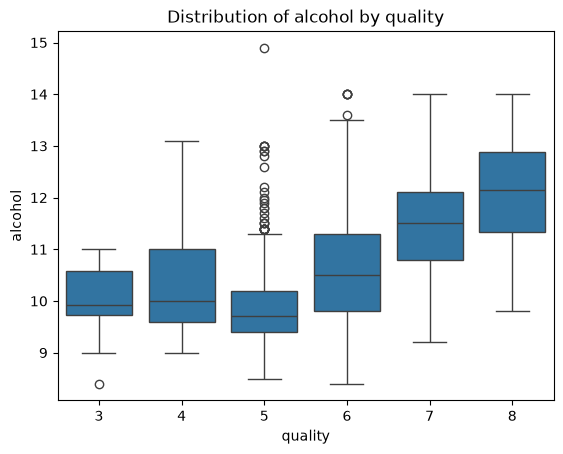

In [8]:
sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)
plt.title("Distribution of alcohol by quality")
plt.show()

#### Distribution of Alcohol by Quality

A box plot was used to examine the distribution of alcohol content across the different wine quality scores.

The plot shows that:

* The median alcohol content for wines with quality scores of **3**, **4**, and **5** is approximately **10% alcohol by volume (ABV)**.
* The median alcohol content increases for quality scores of **6**, **7**, and **8**, reaching approximately **12% ABV** for the highest-quality wines.
* The quality score of **5** contains numerous observations above the upper whisker, indicating the presence of several wines with unusually high alcohol content relative to the rest of the wines in this quality category.

Overall, the box plot suggests a positive relationship between alcohol content and wine quality. As the quality score increases, the median alcohol content also tends to increase. This observation is consistent with the correlation analysis, which identified alcohol as the feature with the strongest positive correlation (0.48) with wine quality.
